I. Introduction & Structural Motivation
* The Research Question: Timing song releases to maximize NPV in a crowded digital market.
* The Logic: Cite Rust (1987) and Einav (2007).
* The Functional Form: Define the Double-Exponential (Bass-style) Diffusion model for streams.
    * $S_{ia} = A_i(x_\tau) \cdot [ \exp(-\gamma_i a) - \exp(-\alpha_i a) ] + \epsilon_{ia}$


$$V(x_t) = \max \left\{ \underbrace{\mathbb{E} \left[ \sum_{\tau=t}^{\infty} \beta^{\tau-t} R(x_t, S_{i,\tau-t}) \right]}_{\text{Release Now}}, \underbrace{\beta \mathbb{E} [V(x_{t+1}) | x_t]}_{\text{Wait}} \right\}$$

Where $R$ is revenue, $x_t$ is the market state, and $S_{i,\tau-t}$ is daily streaming volume for track $i$.



II. Data Pipeline & Web Scraping (Tool Practice)
* Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.
* Feature Engineering: Constructing the "Stochastic Process" ($x_t$):
* Genre-specific "Market Heat" indices.
    * Competitor count variables.
    * Handling "off-chart" tracks via zero-padding (addressing the censoring issue).


In [31]:
%pip install python-dotenv kaggle spotipy pandas matplotlib numpy statsmodels scipy scikit-learn jax optax


  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.1 MB 36.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 29.5 MB/s  0:00:00
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 3.1/3.1 MB 16.5 MB/s  0:00:00
   ---------------------------------------- 0.0/64.2 MB ? eta -:--:--
   - -------------------------------------- 3.1/64.2 MB 16.8 MB/s eta 0:00:04
   --- ------------------------------------ 6.3/64.2 MB 14.8 MB/s eta 0:00:04
   ----- ---------------------------------- 9.2/64.2 MB 14.6 MB/s eta 0:00:04
   ------- -------------------------------- 12.1/64.2 MB 14.0 MB/s eta 0:00:04
   --------- ------------------------------ 15.2

In [1]:
#Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.
from download_kaggle_data import download_kaggle_data

download_kaggle_data("maharshipandya/-spotify-tracks-dataset")
download_kaggle_data("jfreyberg/spotify-chart-data")


Authenticated with Kaggle.
Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
Download complete! You can now access the CSVs in the /data folder.
Authenticated with Kaggle.
Dataset URL: https://www.kaggle.com/datasets/jfreyberg/spotify-chart-data
Download complete! You can now access the CSVs in the /data folder.


In [1]:
import pandas as pd

# Load your data
charts_df = pd.read_csv('../data/charts.csv')
dataset_df = pd.read_csv('../data/dataset.csv')

# Drop duplicates
dataset_df = dataset_df.drop_duplicates(subset='track_id')

# Perform the Inner Join
merged_df = pd.merge(charts_df, dataset_df, on='track_id', how='inner')

print(f"Rows in original charts: {len(charts_df)}")
print(f"Rows after inner merge: {len(merged_df)}")

Rows in original charts: 5428021
Rows after inner merge: 1336013


"Due to API constraints (24 hour lockout for rate violations), the release date for tracks in the sample was approximated using the date of the track's first appearance on the Spotify Charts, rather than directly from Spotify."

In [2]:
# Step 1: Ensure the original 'date' is a datetime object first
merged_df['date'] = pd.to_datetime(merged_df['date'], format='mixed')

# Step 2: Create the proxy dates (the first time each track appeared)
proxy_dates = merged_df.groupby('track_id')['date'].min().reset_index()
proxy_dates.columns = ['track_id', 'approx_release_date']

# Step 3: Now merge the proxy dates BACK into the main dataframe
merged_df = pd.merge(merged_df, proxy_dates, on='track_id')

# Step 4: Calculate Age
merged_df['age_days'] = (merged_df['date'] - merged_df['approx_release_date']).dt.days

print("Success! 'age_days' is now calculated.")

Success! 'age_days' is now calculated.


count    1.336013e+06
mean     4.709669e+02
std      6.149870e+02
min      0.000000e+00
25%      9.800000e+01
50%      2.450000e+02
75%      5.530000e+02
max      3.546000e+03
Name: age_days, dtype: float64


<Axes: >

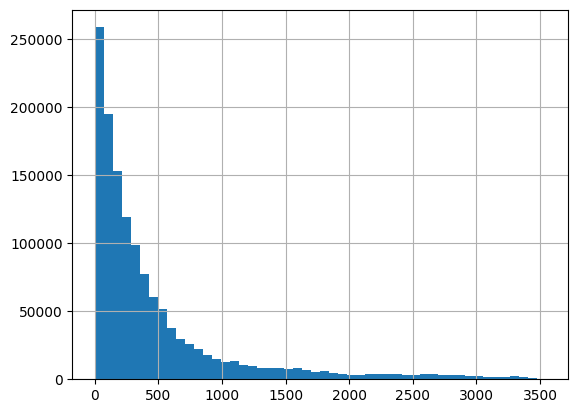

In [3]:

# Check the distribution
print(merged_df['age_days'].describe())

# Plot a quick histogram to see the 'decay' potential
merged_df['age_days'].hist(bins=50)

Feature Engineering: Constructing the "Stochastic Process" ($x_t$):
This includes: market heat, competitor releases, genre trends

In [4]:
#Genre-specific "Market Heat" indices.

#---Competitor count variables.

import numpy as np

# 1. Aggregate daily/weekly streams to get 'Market Heat'
# We group by the chart date to see the total activity in the market
market_heat = merged_df.groupby('date')['streams'].sum().reset_index()
market_heat.columns = ['date', 'x_t']

#adding genre specific heat
genre_heat = merged_df.groupby(['date', 'track_genre'])['streams'].sum().reset_index()
genre_heat.columns = ['date', 'track_genre', 'x_g_t']


# Merge the aggregate heat back to the main dataframe
merged_state_df = pd.merge(merged_df, market_heat, on='date', how='inner')
# Then the genre heat (matches on both date and genre)
merged_state_df = pd.merge(merged_state_df, genre_heat, on=['date', 'track_genre'], how='left')

merged_state_df['log_x_t'] = np.log(merged_state_df['x_t'])
merged_state_df['log_x_g_t'] = np.log(merged_state_df['x_g_t'])

In [5]:
import ast

def fix_artist_column(val):
    # If it's already a list, keep it
    if isinstance(val, list):
        return val
    # If it's a string that looks like a list, convert it
    if isinstance(val, str):
        val = val.strip()
        if val.startswith('[') and val.endswith(']'):
            try:
                return ast.literal_eval(val)
            except:
                # If literal_eval fails, try manual splitting
                return [a.strip("'\" ") for a in val[1:-1].split(',')]
        return [val] # Treat single name strings as a 1-item list
    return []

# Apply the fix
merged_state_df['artists_x'] = merged_state_df['artists_x'].apply(fix_artist_column)

# VERIFICATION: This must be higher than the original count now
exploded_df = merged_state_df.explode('artists_x')
print(f"Original rows: {len(merged_state_df)}")
print(f"Exploded rows: {len(exploded_df)}")

Original rows: 1336013
Exploded rows: 2112730


In [6]:
# 1. Calculate the 'Power' of every individual artist
artist_power = exploded_df.groupby('artists_x')['streams'].mean().to_dict()

# 2. Pick the 'Alpha' artist for every track
def get_alpha(artist_list):
    # Find the artist in the list with the highest mean streams
    return max(artist_list, key=lambda x: artist_power.get(x, 0))

merged_state_df['dominant_artist'] = merged_state_df['artists_x'].apply(get_alpha)

print("Dominant Artists found:")
print(merged_state_df['dominant_artist'].value_counts().head(10))

Dominant Artists found:
dominant_artist
Bad Bunny           53886
Dua Lipa            32287
Billie Eilish       30137
The Weeknd          29505
XXXTENTACION        26304
Ed Sheeran          23731
The Chainsmokers    20922
Halsey              18991
Travis Scott        18676
Ariana Grande       18542
Name: count, dtype: int64


In [7]:
# 1. Identify top 50 dominant artists to use as Fixed Effects
top_50_names = merged_state_df['dominant_artist'].value_counts().nlargest(50).index

# 2. Create a 'Group' column: Artist Name or 'Other'
merged_state_df['fe_group'] = merged_state_df['dominant_artist'].apply(
    lambda x: x if x in top_50_names else 'Other'
)

# 3. Create Dummy Matrix (drop_first=True to avoid the Dummy Variable Trap)
artist_dummies = pd.get_dummies(merged_state_df['fe_group'], prefix='art', drop_first=True)
dummy_cols = artist_dummies.columns.tolist()

# 4. Join back to the main dataframe
merged_state_df = pd.concat([merged_state_df, artist_dummies], axis=1)

III. Estimation of the Stochastic Process (Paul's "Step 1")
* The Optimization Problem: Using SGD (via Flux.jl or Optim.jl) to recover parameters.
* Incidental Parameters Solution: Instead of song-specific $\gamma$, model $\gamma$ as a function of track features (energy, tempo, artist followers).
* Testing: Unit tests to ensure the gradient of the loss function is behaving correctly.


Bivariate Stochastic Specification

We define the state vector as $\mathbf{X}_t = [\ln(x_t), \ln(x_{g,t})]'$. The system of equations looks like this:

$$\begin{bmatrix} 
\ln(x_t) \\ \ln(x_{g,t}) 
\end{bmatrix} = 
\begin{bmatrix} 
\phi_{11} & \phi_{12} \\ 
\phi_{21} & \phi_{22} 
\end{bmatrix} 
\begin{bmatrix} 
\ln(x_{t-1}) \\ \ln(x_{g,t-1}) 
\end{bmatrix} + 
\begin{bmatrix} 
\epsilon_{1,t} \\ \epsilon_{2,t} 
\end{bmatrix}$$

Where:$\phi_{11}, \phi_{22}$: Own-persistence (how much the market/genre stays the same).
$\phi_{12}, \phi_{21}$: Cross-persistence (e.g., does a hot market today predict a hot genre tomorrow?).
$\epsilon \sim N(0, \Sigma)$: Shocks, where $\Sigma$ is the covariance matrix.

In [8]:
from statsmodels.tsa.api import VAR

# 1. Prepare the time-series data
# We need a dataframe where each row is a date and columns are log-states
ts_data = merged_state_df.groupby('date')[['log_x_t', 'log_x_g_t']].mean().dropna()

# 2. Fit the VAR model (Order 1 for your AR(1) logic)
model = VAR(ts_data)
results = model.fit(1)

# 3. Extract your transition parameters
# The coefficient matrix (Phi)
phi = results.coefs[0] 
# The covariance of shocks (Sigma)
sigma = results.sigma_u 

print("Transition Matrix (Phi):")
print(phi)

print("Covariance Matrix (Sigma):")
print(sigma)

Transition Matrix (Phi):
[[ 0.88178543  0.10644973]
 [-0.05867531  1.04329281]]
Covariance Matrix (Sigma):
            log_x_t  log_x_g_t
log_x_t    0.061226   0.050672
log_x_g_t  0.050672   0.046563


c:\Users\Bradley\Documents\Econ622\econ622-project\track-release-estimation\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


The characteristic equation for your matrix $\Phi$ is:$$\det(\Phi - \lambda I) = 0$$Where $\lambda$ are the eigenvalues. In a $2 \times 2$ system, you'll have two: $\lambda_1$ and $\lambda_2$.

In [9]:
import numpy as np

# Assuming 'results' is your fitted VAR model from the previous step
# We extract the coefficients for the lag-1 terms
phi = results.coefs[0] 

# Calculate eigenvalues
eigenvalues = np.linalg.eigvals(phi)

print("Eigenvalues of the VAR transition matrix:")
for i, ev in enumerate(eigenvalues):
    modulus = np.abs(ev)
    print(f"Lambda {i+1}: {ev:.4f} (Modulus: {modulus:.4f})")

# Stationarity Check
if all(np.abs(eigenvalues) < 1):
    print("\nSystem is stationary. The Bellman equation should converge.")
else:
    print("\nWarning: System is non-stationary. Check your log-transformations.")

Eigenvalues of the VAR transition matrix:
Lambda 1: 0.9460 (Modulus: 0.9460)
Lambda 2: 0.9791 (Modulus: 0.9791)

System is stationary. The Bellman equation should converge.


The non-linear least squares (NLLS) solver is minimizing the residuals of your structural decay function. Based on your specific implementation with artist fixed effects and market/genre states, the equation for the predicted streams $y_{i,t}$ of track $i$ at age $a$ is:$$y_{i,t} = A_{i, \tau} \times \left[ e^{-\gamma a} - e^{-\alpha a} \right]$$

Where the initial potential $A_{i, \tau}$ is defined as the linear combination of your fixed effects and the log-state variables at the time of release $\tau$:$$A_{i, \tau} = \underbrace{\sum_{j=1}^{J} \eta_j \mathbb{1}_{i,j}}_{\text{Artist Fixed Effects}} + \beta_m \ln(x_\tau) + \beta_g \ln(x_{g,\tau})$$

Variables Definition:
$y_{i,t}$: Predicted streaming volume for track $i$ at time $t$.
$\eta_j$: The estimated fixed effect (weight) for artist $j$.
$\mathbb{1}_{i,j}$: An indicator (dummy) variable that equals 1 if the dominant artist of track $i$ is artist $j$, and 0 otherwise.
$\beta_m, \beta_g$: The state sensitivity coefficients for the aggregate market ($x$) and specific genre ($x_g$).
$x_\tau, x_{g,\tau}$: The realized market and genre "heat" at the moment the track was released (age 0).
$\gamma$: The structural decay parameter (how fast the song fades).
$\alpha$: The structural growth/diffusion parameter (how fast the song reaches its peak).

In [10]:
from scipy.optimize import curve_fit

# Define the structural function
def streaming_decay_model_fe(data, beta_m, beta_g, gamma, alpha, *artist_weights):
    # Unpack the fixed state data
    age, x_tau, x_g_tau = data[:3]
    # Unpack the matrix of dummy indicators (rows = observations, cols = artists)
    dummy_matrix = data[3:]
    
    # Calculate the Fixed Effect component: sum of (Dummy_j * Weight_j)
    # This is essentially the Artist-specific Intercept
    artist_intercepts = np.dot(np.array(artist_weights), dummy_matrix)
    
    # Structural Ai: Now Includes Fixed Effects + Market State + Genre State
    A_i = artist_intercepts + (beta_m * np.log(x_tau)) + (beta_g * np.log(x_g_tau))
    
    # Double exponential decay
    return A_i * (np.exp(-np.clip(gamma * age, 0, 20)) - np.exp(-np.clip(alpha * age, 0, 20)))


To ensure the curve_fit doesn't crash, we need to map the Release-Day Heat ($x_\tau$) to every row of the track, as discussed. If you use the daily heat instead of the release heat, the $A_i$ parameter will fluctuate every day, which violates the structural assumption that $A_i$ is the fixed "potential" determined at launch.

By including these dummies, you’ve essentially performed a Non-Linear Fixed Effects Regression.$\beta_m$ and $\beta_g$ are now "Within-Artist" estimates. They tell you how much a specific artist's track is boosted by a good market, controlling for that artist's average popularity.In your Bellman Equation, you can now simulate different "Artist Types." You can see if the optimal release timing for a "Superstar" (high $\eta_j$) differs from an "Other" artist (low baseline).How do the estimates look? If $\beta_m$ or $\beta_g$ decreased compared to your previous run, it’s because the Artist Fixed Effects are successfully soaking up the "Superstar" variance that was previously biasing your market coefficients!

In [11]:

# 1. Isolate the heat at Age 0
release_lookup = merged_state_df[merged_state_df['age_days'] == 0][['track_id', 'x_t', 'x_g_t']]
release_lookup = release_lookup.drop_duplicates(subset=['track_id'])
release_lookup.columns = ['track_id', 'x_tau', 'x_g_tau']

# Merge this back so each observation knows its "Birth Market Condition"
est_df = pd.merge(merged_state_df, release_lookup, on='track_id', how='inner').dropna()

# Clean up for the Optimizer
# Filter out non-positive values to avoid log(0) and ensure age starts at 0
est_df = est_df[(est_df['x_tau'] > 0) & (est_df['x_g_tau'] > 0) & (est_df['age_days'] >= 0)]

# Normalize by the mean or a fixed scale factor
# This ensures both variables are roughly in the same neighborhood (around 1.0)
est_df['x_tau_norm'] = est_df['x_tau'] / 1e9
est_df['x_g_tau_norm'] = est_df['x_g_tau'] / 1e6

# 1. Identify unique tracks
unique_tracks = est_df['track_id'].unique()


# 2. Sub-sample 5% of tracks (about 65k rows, which is plenty for NLLS)
np.random.seed(42) # For reproducibility
sample_ids = np.random.choice(unique_tracks, size=int(len(unique_tracks) * 0.05), replace=False)
est_df_sub = est_df[est_df['track_id'].isin(sample_ids)]

# 4. Cast only the numeric columns needed for the regression to float32
# This includes the dummy columns we created earlier
dummy_cols = [col for col in est_df_sub.columns if col.startswith('art_')]
regression_cols = ['age_days', 'x_tau', 'x_g_tau', 'streams'] + dummy_cols

#for col in regression_cols:
#    est_df_sub[col] = pd.to_numeric(est_df_sub[col], errors='coerce').astype('float32')

# Drop NaNs and verify size
est_df_sub = est_df_sub.dropna(subset=regression_cols)
print(f"Subsample prepared: {est_df_sub.shape[0]} rows.")


Subsample prepared: 60338 rows.


f(t)=te
−λt

The peak is at:

t
∗
=
λ
1
	​


Peak value:

f(t
∗
)=
λ
1
	​

e
−1

In [12]:
import jax
import jax.numpy as jnp
import optax

# The structural model in JAX
def model_fn(params, age, x_tau, x_g_tau, artist_indices):
    beta_m = jnp.exp(params['beta_m'])
    beta_g = jnp.exp(params['beta_g'])
    lambda_ = jnp.exp(params['log_lambda'])
    
    eta = params['artist_effects']
    artist_fe = eta[artist_indices]
    
    A_i = artist_fe + beta_m * x_tau + beta_g * x_g_tau
    
    age = age / 365.0
    
    # NO normalization
    decay = age * jnp.exp(-lambda_ * age)
    
    return A_i * decay

def loss_fn(params, age, x_tau, x_g_tau, artist_indices, y_true):
    preds = model_fn(params, age, x_tau, x_g_tau, artist_indices)
    loss = jnp.mean((preds - y_true)**2)
    
    reg = 1e-4 * jnp.mean(params['artist_effects']**2)
    loss += reg
    return loss

In [13]:
key = jax.random.PRNGKey(42)

# 1. Map all artists in the full dataset to integer IDs
all_artists = est_df['fe_group'].unique()
artist_map_full = {name: i for i, name in enumerate(all_artists)}

# 2. Convert everything to JAX arrays at once
# We use float32 to save 50% memory compared to the default float64
age_full = jnp.array(est_df['age_days'].values)
x_tau_full = jnp.array(est_df['x_tau_norm'].values)
x_g_tau_full = jnp.array(est_df['x_g_tau_norm'].values)
y_full = jnp.array(est_df['streams'].values)
idx_full = jnp.array(est_df['fe_group'].map(artist_map_full).values)

# 3. Re-initialize params for the larger artist vector
num_artists_full = len(all_artists)
params = {
    'beta_m': jnp.log(jnp.array(1.0)),
    'beta_g': jnp.log(jnp.array(1.0)),
    'log_lambda': jnp.log(jnp.array(1.5)),
    'artist_effects': jax.random.normal(key, (num_artists_full,)) * 0.1
}

optimizer = optax.multi_transform(
    {
        'fast': optax.adam(1e-3),
        'slow': optax.adam(1e-3),
        'fe': optax.adam(5e-3)
    },
    {
        'beta_m': 'fast',
        'beta_g': 'fast',
        'log_lambda': 'slow',
        'artist_effects': 'fe'
    }
)
opt_state = optimizer.init(params)


@jax.jit
def step(params, opt_state, age, x_tau, x_g_tau, idx, y, key):
    # Optional: Add explicit gradient noise for extra exploration
    loss, grads = jax.value_and_grad(loss_fn)(params, age, x_tau, x_g_tau, idx, y)
    
    # Apply updates
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def get_batches(data_list, batch_size):
    n = data_list[0].shape[0]
    indices = np.random.permutation(n)
    for i in range(0, n, batch_size):
        batch_idx = indices[i:i + batch_size]
        yield [d[batch_idx] for d in data_list]



# 2. Training loop with random shuffling
batch_size = 4096


for epoch in range(30):
    # Shuffle indices at the start of each epoch
    key, subkey = jax.random.split(key)
    perms = jax.random.permutation(subkey, len(y_full))
    
    for i in range(0, len(y_full), batch_size):
        batch_idx = perms[i:i+batch_size]
        
        # Pull the batch
        b_age = age_full[batch_idx]
        b_x = x_tau_full[batch_idx]
        b_xg = x_g_tau_full[batch_idx]
        b_idx = idx_full[batch_idx]
        b_y = y_full[batch_idx] / 1e6
        
        params, opt_state, loss = step(params, opt_state, b_age, b_x, b_xg, b_idx, b_y, key)

    print(f"Loss for epoch {epoch + 1}: {loss}")


Loss for epoch 1: 471.5133361816406
Loss for epoch 2: 276.76873779296875
Loss for epoch 3: 162.06362915039062
Loss for epoch 4: 113.99945831298828
Loss for epoch 5: 77.214111328125
Loss for epoch 6: 50.12278747558594
Loss for epoch 7: 29.86077880859375
Loss for epoch 8: 25.66739273071289
Loss for epoch 9: 26.139188766479492
Loss for epoch 10: 19.876386642456055
Loss for epoch 11: 12.866847038269043
Loss for epoch 12: 11.775091171264648
Loss for epoch 13: 10.941393852233887
Loss for epoch 14: 10.759414672851562
Loss for epoch 15: 6.716064453125
Loss for epoch 16: 6.719011306762695
Loss for epoch 17: 5.989552974700928
Loss for epoch 18: 4.201823711395264
Loss for epoch 19: 8.23993968963623
Loss for epoch 20: 3.7658331394195557
Loss for epoch 21: 2.916043519973755
Loss for epoch 22: 4.324158668518066
Loss for epoch 23: 4.409872055053711
Loss for epoch 24: 6.811277866363525
Loss for epoch 25: 2.6778056621551514
Loss for epoch 26: 6.838768005371094
Loss for epoch 27: 2.21602725982666
Loss f

In [14]:
# Corrected Extraction
# We must reverse the log AND account for the +1.0 floor in the model_fn
real_beta_m = np.exp(float(params['beta_m']))
real_beta_g = np.exp(float(params['beta_g']))
real_lambda = np.exp(float(params['log_lambda']))

# Scaled Artist Effects (since y was /1e6)
# If you want real streams, multiply by 1e6 here
real_artist_effects = np.array(params['artist_effects']) 

print(f"--- Corrected Structural Parameters ---")
print(f"Market Sensitivity (Beta_m): {real_beta_m:,.2f}")
print(f"Genre Sensitivity (Beta_g):  {real_beta_g:,.2f}")
print(f"Decay Rate (lambda):          {real_lambda:.4f} (Half-life: {np.log(2)/real_lambda:.1f} years)")

--- Corrected Structural Parameters ---
Market Sensitivity (Beta_m): 0.22
Genre Sensitivity (Beta_g):  0.20
Decay Rate (lambda):          8.9393 (Half-life: 0.1 years)


In [15]:
# Calculate gradients for a single batch
key, subkey = jax.random.split(key)
loss, grads = jax.value_and_grad(loss_fn)(params, age_full[:100], x_tau_full[:100], x_g_tau_full[:100], idx_full[:100], y_full[:100]/1e6)

print("--- Gradient Magnitude ---")
for k, v in grads.items():
    print(f"{k}: {jnp.linalg.norm(v):.6f}")

--- Gradient Magnitude ---
artist_effects: 0.022833
beta_g: 0.021000
beta_m: 0.000129
log_lambda: 0.039257


IV. Solving the Stopping Problem (Computational Practice)
* The Bellman Framework: Reducing the state space using Paul's "Sufficient Statistic" shortcut ($A_i(x_t)$).
* The Algorithm: Implement either:
    * Value Function Iteration (VFI): For a simplified 1D state space.
    * Reinforcement Learning (DQN): Use ReinforcementLearning.jl to train an agent to "play" the optimal release game.
* Results: A heatmap of the "Exercise Boundary" (at what level of $x_t$ do we pull the trigger?).


V. Conclusion & Discussion
* Comparison of the "AI Agent's" release timing versus the actual historical timing of labels.
* Discussion on the efficiency of the music market.
